
NLU Project: Opinion Mining from Customer Reviews
Task: Aspect-Based Sentiment Analysis (ABSA)
Dataset: SemEval Laptop Reviews
Model: Qwen2.5-1.5B-Instruct + LoRA Fine-Tuning
=============================================================

NOTEBOOK STRUCTURE:
    Cell 1  : Install Dependencies
    Cell 2  : Data Preparation
    Cell 3  : Baseline Evaluation (Before Fine-Tuning)
    Cell 4  : Fine-Tuning with LoRA
    Cell 5  : Post Fine-Tuning Evaluation
    Cell 6  : Plots & Visualizations
    Cell 7  : Inference on Test Data (Phase A & B)
    Cell 8  : Structured Output Showcase


# CELL 1 — Install Dependencies

In [1]:
!pip install unsloth
!pip install --no-deps xformers trl peft accelerate bitsandbytes
!pip install scikit-learn matplotlib seaborn pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 129.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

# CELL 2 — Data Preparation

In [2]:
import pandas as pd
import json
import os

### 2.1 Load Training Data

In [3]:
df_train = pd.read_csv('Laptop_Train_v2.csv')

print("Training Data Shape:", df_train.shape)
print("\nColumns:", df_train.columns.tolist())
print("\nPolarity Distribution:")
print(df_train['polarity'].value_counts())
print("\nSample:")
print(df_train[['Sentence', 'Aspect Term', 'polarity']].head(5).to_string())

Training Data Shape: (2358, 6)

Columns: ['id', 'Sentence', 'Aspect Term', 'polarity', 'from', 'to']

Polarity Distribution:
polarity
positive    987
negative    866
neutral     460
conflict     45
Name: count, dtype: int64

Sample:
                                                                                                                                                                              Sentence     Aspect Term  polarity
0                                                                                              I charge it at night and skip taking the cord with me because of the good battery life.            cord   neutral
1                                                                                              I charge it at night and skip taking the cord with me because of the good battery life.    battery life  positive
2  The tech guy then said the service center does not do 1-to-1 exchange and I have to direct my concern to the "sales" team, which is the r

## 2.2 Convert to Fine-Tuning Format (ChatML for Qwen2.5)

In [ ]:
SYSTEM_PROMPT = (
    "You are an expert in Aspect-Based Sentiment Analysis (ABSA). "
    "Given a product review sentence and a specific aspect term, "
    "classify the sentiment of that aspect as one of: positive, negative, neutral, or conflict. "
    "Return ONLY a JSON object with keys 'aspect' and 'sentiment'."
)

def create_training_sample(row):
    sentence = str(row['Sentence'])
    aspect   = str(row['Aspect Term'])
    polarity = str(row['polarity'])

    user_message = (
        f"Review: {sentence}\n"
        f"Aspect Term: {aspect}\n\n"
        "What is the sentiment of this aspect? Return JSON only."
    )

    target_output = json.dumps({"aspect": aspect, "sentiment": polarity})

    
    text = (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{user_message}<|im_end|>\n"
        f"<|im_start|>assistant\n{target_output}<|im_end|>"
    )

    return {
        "instruction": SYSTEM_PROMPT,
        "input": user_message,
        "output": target_output,
        "text": text
    }


formatted_data = df_train.apply(create_training_sample, axis=1).tolist()

with open('train_data_for_llm.json', 'w', encoding='utf-8') as f:
    json.dump(formatted_data, f, indent=4, ensure_ascii=False)

print(f"\n✅ Prepared {len(formatted_data)} training samples → train_data_for_llm.json")


✅ Prepared 2358 training samples → train_data_for_llm.json


### 2.3 Train/Validation Split (90/10)

In [5]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(formatted_data, test_size=0.1, random_state=42)
print(f"Train: {len(train_data)} | Validation: {len(val_data)}")

with open('train_split.json', 'w', encoding='utf-8') as f:
    json.dump(train_data, f, ensure_ascii=False)

with open('val_split.json', 'w', encoding='utf-8') as f:
    json.dump(val_data, f, ensure_ascii=False)

Train: 2122 | Validation: 236


# CELL 3 — Baseline Evaluation (BEFORE Fine-Tuning)

In [ ]:
from unsloth import FastLanguageModel
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np


model, tokenizer = FastLanguageModel.from_pretrained(
    model_name    = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit  = True,
    trust_remote_code = True,
)


FastLanguageModel.for_inference(model)

def predict_sentiment(sentence, aspect, model, tokenizer, max_new_tokens=50):
    """Run inference and extract predicted sentiment."""
    user_msg = (
        f"Review: {sentence}\n"
        f"Aspect Term: {aspect}\n\n"
        "What is the sentiment of this aspect? Return JSON only."
    )
    prompt = (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{user_msg}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            temperature    = 0.1,
            do_sample      = False,
            pad_token_id   = tokenizer.eos_token_id,
        )

    
    generated = tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    ).strip()

    
    try:
        
        start = generated.find('{')
        end   = generated.rfind('}') + 1
        if start != -1 and end > start:
            result = json.loads(generated[start:end])
            pred = result.get('sentiment', 'unknown').lower().strip()
        else:
            pred = 'unknown'
    except (json.JSONDecodeError, KeyError):
        pred = 'unknown'

    
    valid_labels = ['positive', 'negative', 'neutral', 'conflict']
    if pred not in valid_labels:
        
        for label in valid_labels:
            if label in pred:
                return label
        pred = 'unknown'

    return pred



EVAL_SAMPLES = 100  

print(f"\n🔍 Running Baseline Evaluation on {EVAL_SAMPLES} samples...")

val_subset  = val_data[:EVAL_SAMPLES]
y_true_base = []
y_pred_base = []

for i, sample in enumerate(val_subset):
    try:
        data   = json.loads(sample['output'])
        true   = data['sentiment']
        aspect = data['aspect']
    except Exception:
        continue

    
    lines    = sample['input'].split('\n')
    sentence = lines[0].replace('Review: ', '') if lines else ''

    pred = predict_sentiment(sentence, aspect, model, tokenizer)
    y_true_base.append(true)
    y_pred_base.append(pred)

    if (i + 1) % 20 == 0:
        print(f"  Progress: {i+1}/{EVAL_SAMPLES}")


labels = ['positive', 'negative', 'neutral', 'conflict']

baseline_accuracy = accuracy_score(y_true_base, y_pred_base)
baseline_f1_macro = f1_score(y_true_base, y_pred_base, average='macro', labels=labels, zero_division=0)
baseline_f1_weighted = f1_score(y_true_base, y_pred_base, average='weighted', labels=labels, zero_division=0)

print(f"\n📊 BASELINE RESULTS (Before Fine-Tuning):")
print(f"  Accuracy     : {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"  F1 (Macro)   : {baseline_f1_macro:.4f}")
print(f"  F1 (Weighted): {baseline_f1_weighted:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_true_base, y_pred_base, labels=labels, zero_division=0))


baseline_cm = confusion_matrix(y_true_base, y_pred_base, labels=labels)


baseline_results = {
    "accuracy": baseline_accuracy,
    "f1_macro": baseline_f1_macro,
    "f1_weighted": baseline_f1_weighted,
    "y_true": y_true_base,
    "y_pred": y_pred_base,
    "confusion_matrix": baseline_cm.tolist()
}

with open('baseline_results.json', 'w') as f:
    json.dump({k: v for k, v in baseline_results.items() if k != 'confusion_matrix'}, f, indent=2)
    
with open('baseline_cm.json', 'w') as f:
    json.dump(baseline_cm.tolist(), f)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

  Progress: 60/100


Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  Progress: 80/100


Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  Progress: 100/100

📊 BASELINE RESULTS (Before Fine-Tuning):
  Accuracy     : 0.7900 (79.00%)
  F1 (Macro)   : 0.5209
  F1 (Weighted): 0.7762

  Classification Report:
              precision    recall  f1-score   support

    positive       0.81      0.89      0.85        38
    negative       0.87      0.91      0.89        44
     neutral       0.45      0.28      0.34        18
    conflict       0.00      0.00      0.00         0

   micro avg       0.80      0.79      0.79       100
   macro avg       0.53      0.52      0.52       100
weighted avg       0.77      0.79      0.78       100



# CELL 4 — Fine-Tuning with LoRA

In [ ]:
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import load_dataset


model, tokenizer = FastLanguageModel.from_pretrained(
    model_name    = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit  = True,
    trust_remote_code = True,
)


model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],  
    lora_alpha     = 32,       
    lora_dropout   = 0.05,     
    bias           = "none",
    use_gradient_checkpointing = "unsloth",  
)


total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"Trainable Ratio      : {100 * trainable_params / total_params:.2f}%")


dataset = load_dataset("json", data_files="train_split.json", split="train")
val_dataset = load_dataset("json", data_files="val_split.json", split="train")


training_args = TrainingArguments(
    output_dir                  = "outputs",
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    warmup_steps                = 10,
    num_train_epochs            = 3,
    learning_rate               = 2e-4,
    fp16                        = not torch.cuda.is_bf16_supported(),
    bf16                        = torch.cuda.is_bf16_supported(),
    logging_steps               = 10,
    eval_strategy               = "steps",   
    eval_steps                  = 50,
    save_strategy               = "steps",
    save_steps                  = 50,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,
    optim                       = "adamw_8bit",
    seed                        = 42,
    report_to                   = "none",
)


trainer = SFTTrainer(
    model            = model,
    train_dataset    = dataset,
    eval_dataset     = val_dataset,
    dataset_text_field = "text",
    max_seq_length   = 2048,
    args             = training_args,
)


print("\n🚀 Starting Fine-Tuning...")
trainer_stats = trainer.train()


training_log = trainer.state.log_history
with open('training_log.json', 'w') as f:
    json.dump(training_log, f, indent=2)

print("\n✅ Fine-Tuning Complete!")
print(f"  Total steps  : {trainer_stats.global_step}")
print(f"  Training time: {trainer_stats.metrics['train_runtime']:.1f}s")
print(f"  Final loss   : {trainer_stats.metrics['train_loss']:.4f}")


model.save_pretrained("finetuned_model")
tokenizer.save_pretrained("finetuned_model")
print("\n✅ Model saved to finetuned_model/")

Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Total Parameters     : 907,081,216
Trainable Parameters : 18,464,768
Trainable Ratio      : 2.04%


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Step,Training Loss,Validation Loss
50,0.584853,0.569296
100,0.551318,0.549742
150,0.544928,0.523060
200,0.554866,0.500409
250,0.487102,0.472008
300,0.370424,0.467189
350,0.357472,0.457509
400,0.374684,0.434398
450,0.344451,0.420351
500,0.321216,0.400272


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


✅ Fine-Tuning Complete!
  Total steps  : 798
  Training time: 1608.1s
  Final loss   : 0.3907


Unsloth: Restored added_tokens_decoder metadata in finetuned_model/tokenizer_config.json.



✅ Model saved to finetuned_model/


# CELL 5 — Post Fine-Tuning Evaluation

In [ ]:

from unsloth import FastLanguageModel

model_ft, tokenizer_ft = FastLanguageModel.from_pretrained(
    model_name    = "finetuned_model",
    max_seq_length = 2048,
    load_in_4bit  = True,
)
FastLanguageModel.for_inference(model_ft)

print(f"\n🔍 Running Post Fine-Tuning Evaluation on {EVAL_SAMPLES} samples...")

y_true_ft = []
y_pred_ft = []

for i, sample in enumerate(val_subset):
    try:
        data   = json.loads(sample['output'])
        true   = data['sentiment']
        aspect = data['aspect']
    except Exception:
        continue

    lines    = sample['input'].split('\n')
    sentence = lines[0].replace('Review: ', '') if lines else ''

    pred = predict_sentiment(sentence, aspect, model_ft, tokenizer_ft)
    y_true_ft.append(true)
    y_pred_ft.append(pred)

    if (i + 1) % 20 == 0:
        print(f"  Progress: {i+1}/{EVAL_SAMPLES}")


ft_accuracy    = accuracy_score(y_true_ft, y_pred_ft)
ft_f1_macro    = f1_score(y_true_ft, y_pred_ft, average='macro', labels=labels, zero_division=0)
ft_f1_weighted = f1_score(y_true_ft, y_pred_ft, average='weighted', labels=labels, zero_division=0)
ft_cm          = confusion_matrix(y_true_ft, y_pred_ft, labels=labels)

print(f"\n📊 FINE-TUNED MODEL RESULTS:")
print(f"  Accuracy     : {ft_accuracy:.4f} ({ft_accuracy*100:.2f}%)")
print(f"  F1 (Macro)   : {ft_f1_macro:.4f}")
print(f"  F1 (Weighted): {ft_f1_weighted:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_true_ft, y_pred_ft, labels=labels, zero_division=0))


print("\n" + "="*55)
print("📈 COMPARISON: Baseline vs Fine-Tuned")
print("="*55)
print(f"{'Metric':<20} {'Baseline':>12} {'Fine-Tuned':>12} {'Δ':>10}")
print("-"*55)
for metric, base_val, ft_val in [
    ("Accuracy",      baseline_accuracy,    ft_accuracy),
    ("F1 (Macro)",    baseline_f1_macro,    ft_f1_macro),
    ("F1 (Weighted)", baseline_f1_weighted, ft_f1_weighted),
]:
    delta = ft_val - base_val
    sign  = "+" if delta >= 0 else ""
    print(f"{metric:<20} {base_val:>12.4f} {ft_val:>12.4f} {sign+f'{delta:.4f}':>10}")
print("="*55)

with open('ft_cm.json', 'w') as f:
    json.dump(ft_cm.tolist(), f)

ft_results = {
    "accuracy": ft_accuracy,
    "f1_macro": ft_f1_macro,
    "f1_weighted": ft_f1_weighted,
}
with open('ft_results.json', 'w') as f:
    json.dump(ft_results, f, indent=2)

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🔍 Running Post Fine-Tuning Evaluation on 100 samples...


...

  Progress: 60/100


Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  Progress: 80/100


Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  Progress: 100/100

📊 FINE-TUNED MODEL RESULTS:
  Accuracy     : 0.8400 (84.00%)
  F1 (Macro)   : 0.5965
  F1 (Weighted): 0.8415

  Classification Report:
              precision    recall  f1-score   support

    positive       0.89      0.89      0.89        38
    negative       0.91      0.89      0.90        44
     neutral       0.58      0.61      0.59        18
    conflict       0.00      0.00      0.00         0

    accuracy                           0.84       100
   macro avg       0.60      0.60      0.60       100
weighted avg       0.84      0.84      0.84       100


📈 COMPARISON: Baseline vs Fine-Tuned
Metric                   Baseline   Fine-Tuned          Δ
-------------------------------------------------------
Accuracy                   0.7900       0.8400    +0.0500
F1 (Macro)                 0.5209       0.5965    +0.0755
F1 (Weighted)              0.7762       0.8415    +0.0653


# CELL 6 — Plots & Visualizations

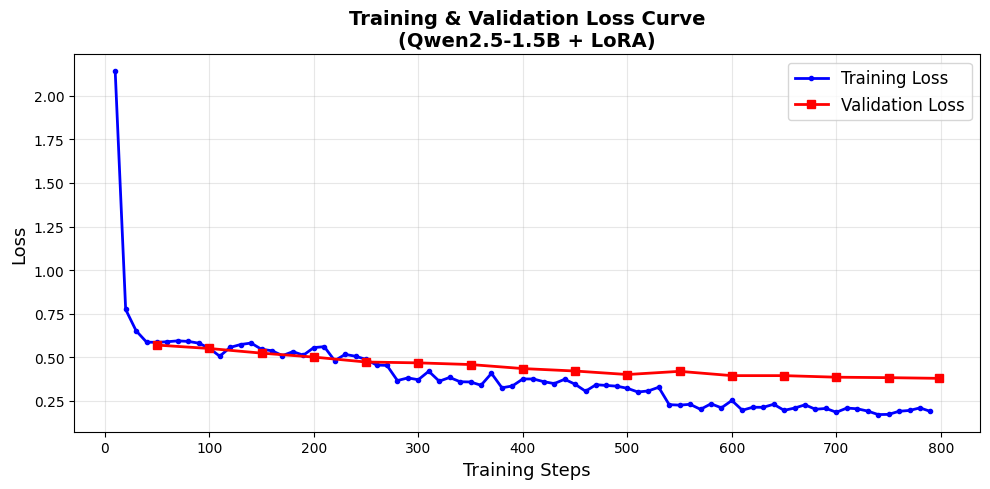

✅ Saved: plot_training_loss.png


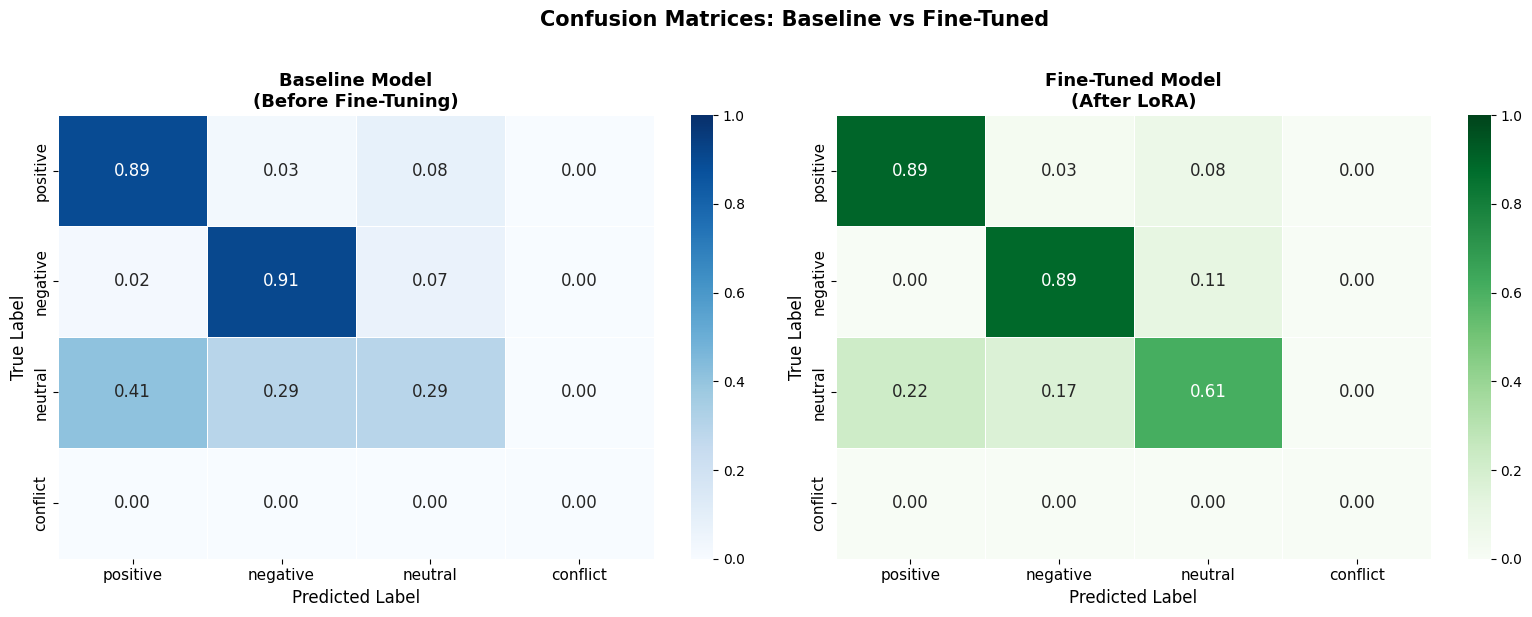

✅ Saved: plot_confusion_matrices.png


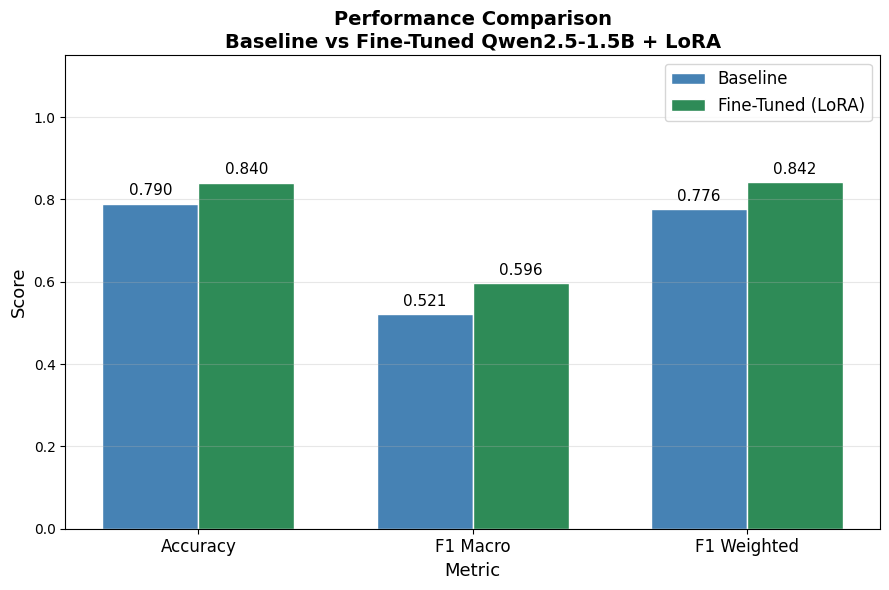

✅ Saved: plot_metrics_comparison.png


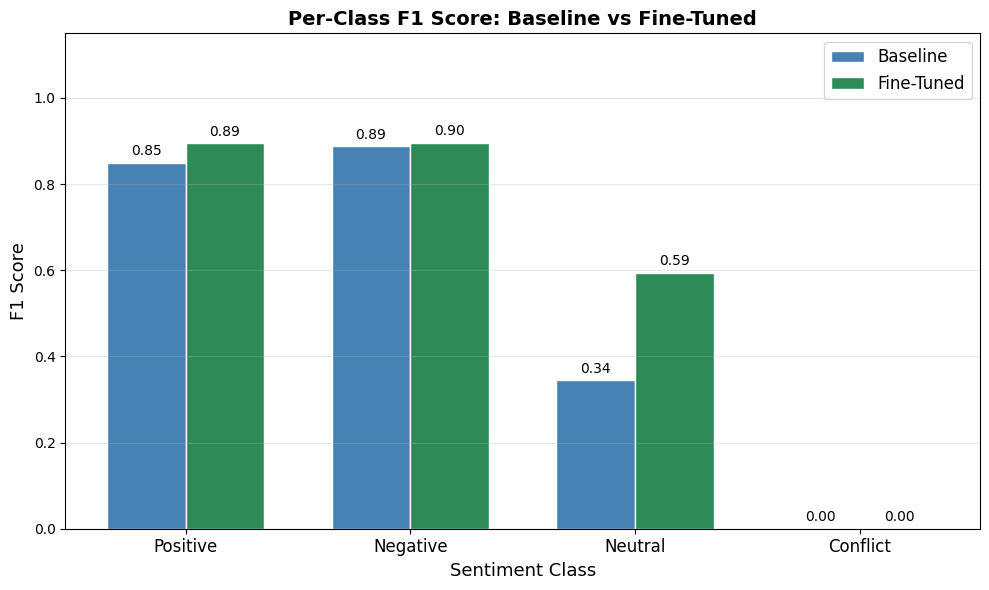

✅ Saved: plot_per_class_f1.png


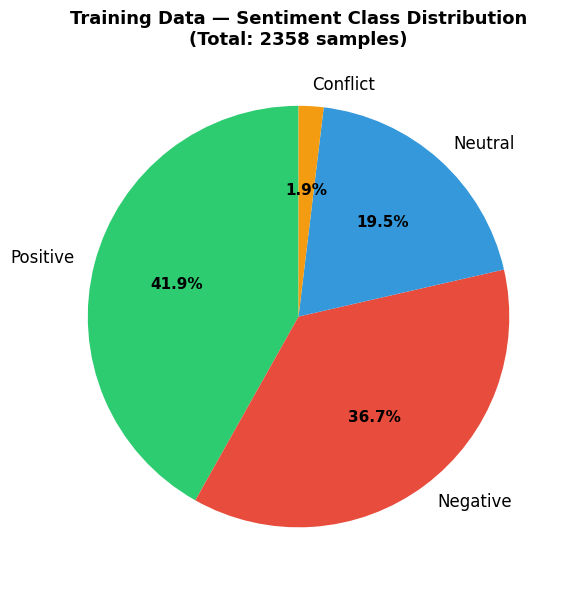

✅ Saved: plot_class_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np


with open('training_log.json') as f:
    log = json.load(f)

train_steps  = [e['step'] for e in log if 'loss' in e]
train_losses = [e['loss'] for e in log if 'loss' in e]
eval_steps   = [e['step'] for e in log if 'eval_loss' in e]
eval_losses  = [e['eval_loss'] for e in log if 'eval_loss' in e]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, 'b-o', markersize=3, label='Training Loss', linewidth=2)
if eval_steps:
    plt.plot(eval_steps, eval_losses, 'r-s', markersize=6, label='Validation Loss', linewidth=2)
plt.xlabel('Training Steps', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.title('Training & Validation Loss Curve\n(Qwen2.5-1.5B + LoRA)', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_training_loss.png")


with open('baseline_cm.json') as f:
    cm_base = np.array(json.load(f))
with open('ft_cm.json') as f:
    cm_ft = np.array(json.load(f))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cm, title, cmap in [
    (axes[0], cm_base, 'Baseline Model\n(Before Fine-Tuning)', 'Blues'),
    (axes[1], cm_ft,   'Fine-Tuned Model\n(After LoRA)',       'Greens'),
]:

    cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap=cmap,
        xticklabels=labels, yticklabels=labels,
        ax=ax, linewidths=0.5, vmin=0, vmax=1,
        annot_kws={"size": 12}
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', labelsize=11)

plt.suptitle('Confusion Matrices: Baseline vs Fine-Tuned', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_confusion_matrices.png")


metrics_names   = ['Accuracy', 'F1 Macro', 'F1 Weighted']
baseline_scores = [baseline_accuracy, baseline_f1_macro, baseline_f1_weighted]
ft_scores       = [ft_accuracy, ft_f1_macro, ft_f1_weighted]

x     = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, ft_scores,       width, label='Fine-Tuned (LoRA)', color='seagreen', edgecolor='white')


for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Performance Comparison\nBaseline vs Fine-Tuned Qwen2.5-1.5B + LoRA',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_metrics_comparison.png")


from sklearn.metrics import f1_score

f1_per_class_base = f1_score(y_true_base, y_pred_base, average=None, labels=labels, zero_division=0)
f1_per_class_ft   = f1_score(y_true_ft,   y_pred_ft,   average=None, labels=labels, zero_division=0)

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, f1_per_class_base, width, label='Baseline', color='steelblue', edgecolor='white')
ax.bar(x + width/2, f1_per_class_ft,   width, label='Fine-Tuned', color='seagreen', edgecolor='white')

for i, (b, f) in enumerate(zip(f1_per_class_base, f1_per_class_ft)):
    ax.text(i - width/2, b + 0.01, f'{b:.2f}', ha='center', va='bottom', fontsize=10)
    ax.text(i + width/2, f + 0.01, f'{f:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Sentiment Class', fontsize=13)
ax.set_ylabel('F1 Score', fontsize=13)
ax.set_title('Per-Class F1 Score: Baseline vs Fine-Tuned', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([l.capitalize() for l in labels], fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_per_class_f1.png")


class_counts = df_train['polarity'].value_counts()
colors_pie   = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    class_counts.values,
    labels=[l.capitalize() for l in class_counts.index],
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax.set_title('Training Data — Sentiment Class Distribution\n(Total: 2358 samples)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot_class_distribution.png")

# CELL 7 — Inference on Test Data (Phase A & B)

In [ ]:
def run_inference_on_test(test_csv_path, output_path, model, tokenizer):
    """Run ABSA inference on test sentences and save predictions."""
    df_test = pd.read_csv(test_csv_path)
    print(f"\nRunning inference on: {test_csv_path} ({len(df_test)} sentences)")

    results = []

    for idx, row in df_test.iterrows():
        sentence = str(row['Sentence'])


        extraction_prompt = (
            f"<|im_start|>system\n"
            f"Extract all product aspect terms from the review. "
            f"Return ONLY a JSON object: {{\"aspects\": [\"term1\", \"term2\", ...]}}<|im_end|>\n"
            f"<|im_start|>user\n{sentence}<|im_end|>\n"
            f"<|im_start|>assistant\n"
        )

        inputs = tokenizer([extraction_prompt], return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=100, do_sample=False,
                                  temperature=0.1, pad_token_id=tokenizer.eos_token_id)
        generated = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

        try:
            start = generated.find('{')
            end   = generated.rfind('}') + 1
            aspect_data = json.loads(generated[start:end])
            aspects = aspect_data.get('aspects', [])
        except Exception:
            aspects = []


        aspect_sentiments = []
        for aspect in aspects:
            if not aspect.strip():
                continue
            sentiment = predict_sentiment(sentence, aspect, model, tokenizer)
            aspect_sentiments.append({
                "aspect": aspect,
                "sentiment": sentiment
            })

        results.append({
            "id": row['id'],
            "sentence": sentence,
            "predictions": aspect_sentiments
        })

        if (idx + 1) % 50 == 0:
            print(f"  Processed: {idx + 1}/{len(df_test)}")


    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(results, f, indent=4, ensure_ascii=False)

    print(f"✅ Predictions saved to: {output_path}")
    return results



results_a = run_inference_on_test(
    'Laptops_Test_Data_PhaseA.csv',
    'predictions_phase_a.json',
    model_ft, tokenizer_ft
)


results_b = run_inference_on_test(
    'Laptops_Test_Data_PhaseB.csv',
    'predictions_phase_b.json',
    model_ft, tokenizer_ft
)

Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Running inference on: Laptops_Test_Data_PhaseA.csv (800 sentences)


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50

  Processed: 50/800


Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generat

...

  Processed: 700/800


Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generat

  Processed: 750/800


Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generat

  Processed: 800/800
✅ Predictions saved to: predictions_phase_b.json


# CELL 8 — Structured Output Showcase

In [ ]:

example_sentences = [
    "The battery life is amazing but the keyboard feels really cheap.",
    "Boot time is super fast and the screen resolution is crystal clear.",
    "The touchpad is unresponsive and customer service was terrible.",
    "Great performance for the price, though it runs a bit hot.",
    "I love the lightweight design but the speakers sound hollow.",
]

print("\nModel: Qwen2.5-1.5B + LoRA Fine-Tuned")
print(f"Task : Aspect-Based Sentiment Analysis\n")

for i, sentence in enumerate(example_sentences, 1):


    extraction_prompt = (
        f"<|im_start|>system\n"
        f"Extract all product aspect terms from the review. "
        f"Return ONLY a JSON object: {{\"aspects\": [\"term1\", \"term2\", ...]}}<|im_end|>\n"
        f"<|im_start|>user\n{sentence}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

    inputs = tokenizer_ft([extraction_prompt], return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model_ft.generate(**inputs, max_new_tokens=80, do_sample=False,
                                 temperature=0.1, pad_token_id=tokenizer_ft.eos_token_id)
    gen = tokenizer_ft.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

    try:
        s = gen.find('{'); e = gen.rfind('}') + 1
        aspects = json.loads(gen[s:e]).get('aspects', [])
    except Exception:
        aspects = []


    predictions = []
    for aspect in aspects:
        if aspect.strip():
            sentiment = predict_sentiment(sentence, aspect, model_ft, tokenizer_ft)
            predictions.append({"aspect": aspect, "sentiment": sentiment})


    structured_output = {
        "input": sentence,
        "model": "Qwen2.5-1.5B-Instruct + LoRA",
        "task": "Aspect-Based Sentiment Analysis",
        "output": {
            "aspects_found": len(predictions),
            "analysis": predictions
        }
    }

    print(f"Example {i}:")
    print(f"  Input : \"{sentence}\"")
    print(f"  Output: {json.dumps(structured_output['output'], indent=10)}")
    print()


print("\n" + "="*70)
print("📊 PROJECT FINAL SUMMARY")
print("="*70)
print(f"\nModel     : Qwen2.5-1.5B-Instruct (LoRA Fine-Tuned)")
print(f"Dataset   : SemEval Laptop Reviews (2358 training samples)")
print(f"Task      : Aspect-Based Sentiment Analysis (ABSA)")
print(f"Classes   : positive | negative | neutral | conflict")
print()
print(f"{'Metric':<20} {'Before FT':>12} {'After FT':>12} {'Improvement':>12}")
print("-"*58)
print(f"{'Accuracy':<20} {baseline_accuracy:>12.4f} {ft_accuracy:>12.4f} {ft_accuracy-baseline_accuracy:>+12.4f}")
print(f"{'F1 (Macro)':<20} {baseline_f1_macro:>12.4f} {ft_f1_macro:>12.4f} {ft_f1_macro-baseline_f1_macro:>+12.4f}")
print(f"{'F1 (Weighted)':<20} {baseline_f1_weighted:>12.4f} {ft_f1_weighted:>12.4f} {ft_f1_weighted-baseline_f1_weighted:>+12.4f}")
print("="*70)
print("\n✅ All outputs saved:")
print("  - finetuned_model/           → Saved LoRA model weights")
print("  - predictions_phase_a.json   → Test Phase A predictions")
print("  - predictions_phase_b.json   → Test Phase B predictions")
print("  - plot_training_loss.png     → Loss curve")
print("  - plot_confusion_matrices.png → Confusion matrix comparison")
print("  - plot_metrics_comparison.png → Bar chart: Baseline vs Fine-Tuned")
print("  - plot_per_class_f1.png      → Per-class F1 comparison")
print("  - plot_class_distribution.png → Training data distribution")

Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Model: Qwen2.5-1.5B + LoRA Fine-Tuned
Task : Aspect-Based Sentiment Analysis



Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Example 1:
  Input : "The battery life is amazing but the keyboard feels really cheap."
  Output: {
          "aspects_found": 2,
          "analysis": [
                    {
                              "aspect": "battery life",
                              "sentiment": "positive"
                    },
                    {
                              "aspect": "keyboard",
                              "sentiment": "negative"
                    }
          ]
}



Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Example 3:
  Input : "The touchpad is unresponsive and customer service was terrible."
  Output: {
          "aspects_found": 2,
          "analysis": [
                    {
                              "aspect": "touchpad",
                              "sentiment": "negative"
                    },
                    {
                              "aspect": "customer service",
                              "sentiment": "negative"
                    }
          ]
}



Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

Example 4:
  Input : "Great performance for the price, though it runs a bit hot."
  Output: {
          "aspects_found": 3,
          "analysis": [
                    {
                              "aspect": "performance",
                              "sentiment": "positive"
                    },
                    {
                              "aspect": "price",
                              "sentiment": "positive"
                    },
                    {
                              "aspect": "runs",
                              "sentiment": "negative"
                    }
          ]
}



Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Example 5:
  Input : "I love the lightweight design but the speakers sound hollow."
  Output: {
          "aspects_found": 2,
          "analysis": [
                    {
                              "aspect": "design",
                              "sentiment": "positive"
                    },
                    {
                              "aspect": "speakers",
                              "sentiment": "negative"
                    }
          ]
}


📊 PROJECT FINAL SUMMARY

Model     : Qwen2.5-1.5B-Instruct (LoRA Fine-Tuned)
Dataset   : SemEval Laptop Reviews (2358 training samples)
Task      : Aspect-Based Sentiment Analysis (ABSA)
Classes   : positive | negative | neutral | conflict

Metric                  Before FT     After FT  Improvement
----------------------------------------------------------
Accuracy                   0.7900       0.8400      +0.0500
F1 (Macro)                 0.5209       0.5965      +0.0755
F1 (Weighted)              0.7762       0.8415      +0.

In [14]:
model.save_pretrained("finetuned_model")
tokenizer.save_pretrained("finetuned_model")

('finetuned_model/tokenizer_config.json',
 'finetuned_model/chat_template.jinja',
 'finetuned_model/tokenizer.json')